# Семинар "Декораторы в Python"

Краткий опрос:
- Кто смотрел лекцию?
- Кто работал с декораторами раньше?

Опрос по существу:
1. Что такое декоратор?
2. Зачем используется?
3. Какие способы реализации есть в Python?
4. Что можно декорировать в Python?

# Выжимка из лекции

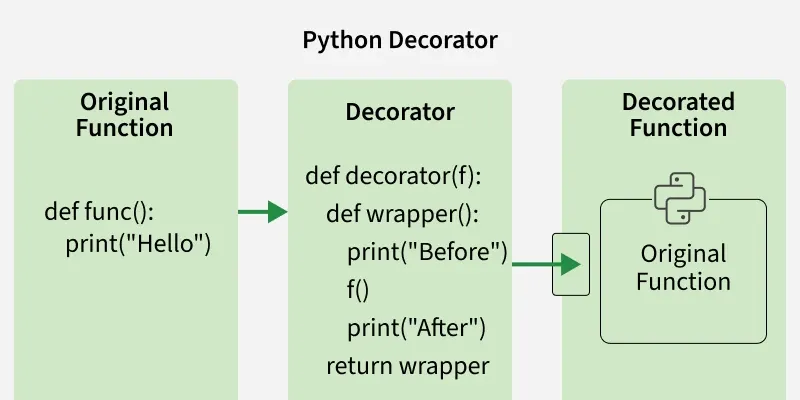

1. Декоратор - это паттерн проектирования, который позволяет добавлять новую логику к вызываемым объектам, не изменяя их исходный код.


2. Декоратор - это функция, которая принимает другую функцию и выполняет дополнительную логику.


У нас есть два способа реализовать декоратор в Python:

## Декоратор-функция

In [5]:
import time


def timed_func(func):
    def wrapped_func(*args, **kwargs):
        start = time.time()
        res = func(*args, **kwargs)
        print(f"I am timed_func. Function {func.__name__} worked: {time.time() - start} seconds")
        return res

    return wrapped_func


@timed_func
def say_hi(name: str) -> None:
    time.sleep(1)
    print(f"Hi, {name}!")

In [ ]:
timed_func(say_hi)("test_name")

In [6]:
say_hi("Megaming")

Hi, Megaming!
I am timed_func. Function say_hi worked: 1.002835988998413 seconds


Алгоритм такой:
1. Объявляем функцию, которая будет нашим декоратором. В качестве аргумента она принимает функцию и возвращает тоже функцию (вложенную)

2. Внутри объявляем вложенную функцию, которая собирает все аргументы в `args` и `kwargs`.

3. Внутри вложенной функции вызываем оригинальную функцию с `args` и `kwargs`. Пишем return результата этого вызова

4. Не забываем в конце декоратора дописать `return <вложенная функция>`

Если хотим создать параметризированный декоратор, добавляется ещё один уровень вложенности:

In [68]:
import datetime
import functools

def amortized_timed_func(call_count: int = 1):
    if call_count < 1:
        raise ValueError("Function must be called at least once!")
    def inner(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            cumulative_time = 0.0
            for _ in range(call_count):
                start = datetime.datetime.now()
                res = func(*args, **kwargs)
                cumulative_time += (datetime.datetime.now() - start).seconds

            print(f"I am amortized_timed_func. In average, function {func.__name__} worked: {cumulative_time/call_count} seconds")
            return res
        return wrapper
    return inner

In [69]:
@amortized_timed_func(5)
def say_hello():
    """Says hello."""
    print("Hello")

In [70]:
print(say_hello.__name__)
print(say_hello.__doc__)

say_hello
Says hello.


In [47]:
amortized_timed_func(1)(print)("some str")

some str
I am amortized_timed_func. In average, function print worked: 0.0 seconds


Важный момент - замыкание

In [ ]:
from typing import Any
from random import randint


def count_calls(func):
    count = 0
    def inner(*args, **kwargs) -> Any:
        nonlocal count
        count += 1
        print(f"Count: {count}")
        return func(*args, **kwargs)
    return inner


@count_calls
def get_random_int(low: int, high: int) -> int:
    return randint(low, high)

@count_calls
def get_random():
    pass

## Декоратор-функтор

Мы помним, что декоратор это функция. Но в python можно вызывать call не только у функций, но и у классов, которые это поддерживают:

In [11]:
class Count:

    def __init__(self, func):
        self.func = func
        self.count = 0

    def __call__(self, *args, **kwargs):
        self.count += 1
        print(self.count)
        res = self.func(*args, **kwargs)
        return res

@Count
def hello_class(name):
    return f"Привет, {name}!"

In [12]:
hello_class("класс")

1


'Привет, класс!'

# Задачи

## Задача 1 (easy)

Давайте напишем декоратор, который будет выводить в консоль информацию определённую справку:

- Время вызова: <текущий datetime>
- Имя функции: <>
- Позиционные аргументы: <>
- Именованные аргументы: <>

In [ ]:

import datetime

# Код декоратора здесь

In [ ]:
@log_call
def say_hi(name: str, need_upper: bool):
    print(f"Hi, {name.upper() if need_upper else name}")

say_hi("Nemo", need_upper=True)

say_hi
('Nemo',)
{'need_upper': True}
2026-04-02 18:16:15.508412
Hi, NEMO


## Задача 2 (easy)

Давайте сделаем аналог `functools.cache` - это безлимитый кэш, который для комбинации аргументов запоминает значение.

In [ ]:
# Нужно написать реализацию для cached_result


@cached_result
def multiply_numbers(a, b):
    return f"Multiplication result = {a * b}"

In [ ]:
multiply_numbers(b=3, a=1)

used cache


'Multiplication result = 2'

## Задача 3 (Easy)

Давайте сделаем декоратор для классов, который будет добавлять классу метод для его экземпляров `copy_with(**kwargs)`

In [ ]:
# Декоратор класса тут:

In [ ]:
@with_copy_with
class Box:
    def __init__(self, w: int, h: int):
        self.w = w
        self.h = h


b = Box(1, 2)
c = b.copy_with(h=10)
print(c.w, c.h)

1 10


In [100]:
Box.__dict__

mappingproxy({'__module__': '__main__',
              '__firstlineno__': 1,
              '__init__': <function __main__.Box.__init__(self, w: int, h: int)>,
              '__static_attributes__': ('h', 'w'),
              '__dict__': <attribute '__dict__' of 'Box' objects>,
              '__weakref__': <attribute '__weakref__' of 'Box' objects>,
              '__doc__': None,
              'copy_with': <function __main__.with_copy_with.<locals>.copy_with(self, *args, **kwargs)>,
              '__slotnames__': []})

## Задача 4 (Medium)

В популярном нынче фреймворке FastAPI используется вот такой способ добавления эндпойнтов:

```python
from fastapi import FastAPI, status

app = FastAPI()

@app.method("/items/", status_code=status.HTTP_201_CREATED)
def create_item(name: str):
    return {"name": name}
```

Вам необходимо сделать свой класс `ModernAPI`, в который точно также можно добавлять методы.

Внутри экземпляра app должен быть набор сохранённых путей и методов. Добавьте так же метод. `resolve_endpoint`, который по указанному пути и аргументам будет выполнять подходящий запрос.

In [ ]:
class ModernAPI: ...

In [ ]:
app = ModernAPI()

@app.method("/items/", status_code=status.HTTP_201_CREATED)
def create_item(name: str):
    return {"name": name}


app.resolve_endpoint()

# Задача 5

Напишите декоратор `@singleton`, который при попытке создать второй и следующие инстансы будет возвращать первый экземпляр.

In [ ]:
...